In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv('../data/clean/clean.csv')
df.head()

,order_id,product,category,quantity,price,city,date,total_price,year,month_number,month
0,ORD1001,Backpack,Accessories,1,1629.00,Hyderabad,2026-03-04,1629.00,2026,3,2026-03
1,ORD1002,Keyboard,Electronics,2,1570.94,Surat,2026-01-23,3141.88,2026,1,2026-01
2,ORD1003,Book,Books,4,407.86,Mumbai,2026-02-25,1631.44,2026,2,2026-02
3,ORD1004,Keyboard,Electronics,5,1530.61,Surat,2026-02-20,7653.05,2026,2,2026-02
4,ORD1005,Tablet,Electronics,5,27549.31,Jaipur,2026-05-31,137746.55,2026,5,2026-05


In [12]:
df.shape

(1000, 11)

In [13]:
df['date']=pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      1000 non-null   str           
 1   product       1000 non-null   str           
 2   category      1000 non-null   str           
 3   quantity      1000 non-null   int64         
 4   price         1000 non-null   float64       
 5   city          1000 non-null   str           
 6   date          1000 non-null   datetime64[us]
 7   total_price   1000 non-null   float64       
 8   year          1000 non-null   int64         
 9   month_number  1000 non-null   int64         
 10  month         1000 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 86.1 KB


In [14]:
df.describe()

,quantity,price,date,total_price,year,month_number
count,1000.000000,1000.000000,1000,1000.000000,1000.0,1000.000000
mean,3.035000,8940.486210,2026-03-31 13:56:38.400000,27620.651090,2026.0,3.491000
min,1.000000,407.430000,2026-01-01 00:00:00,410.560000,2026.0,1.000000
25%,2.000000,1738.235000,2026-02-15 00:00:00,3800.072500,2026.0,2.000000
50%,3.000000,2962.040000,2026-03-31 00:00:00,8488.360000,2026.0,3.000000
75%,4.000000,6263.752500,2026-05-14 00:00:00,20335.462500,2026.0,5.000000
max,5.000000,60347.510000,2026-06-29 00:00:00,299643.450000,2026.0,6.000000
std,1.402049,14229.456287,NaN,50826.518023,0.0,1.686049


In [15]:
print("Unique Products:", df["product"].nunique())
print("Unique Categories:", df["category"].nunique())
print("Unique Cities:", df["city"].nunique())
print("Unique Orders:", df["order_id"].nunique())

Unique Products: 14
Unique Categories: 5
Unique Cities: 10
Unique Orders: 1000


In [16]:
print(df["category"].unique())
print(df["city"].unique())

<StringArray>
['Accessories', 'Electronics', 'Books', 'Fashion', 'Home Appliances']
Length: 5, dtype: str
<StringArray>
['Hyderabad',     'Surat',    'Mumbai',    'Jaipur',     'Delhi', 'Bangalore',
      'Pune', 'Ahmedabad',   'Chennai',   'Kolkata']
Length: 10, dtype: str


In [17]:
total_revenue = df["total_price"].sum()
total_orders = df["order_id"].nunique()
total_quantity = df["quantity"].sum()
average_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Quantity:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 27620651.09
Total Orders: 1000
Total Quantity: 3035
Average Order Value: 27620.65


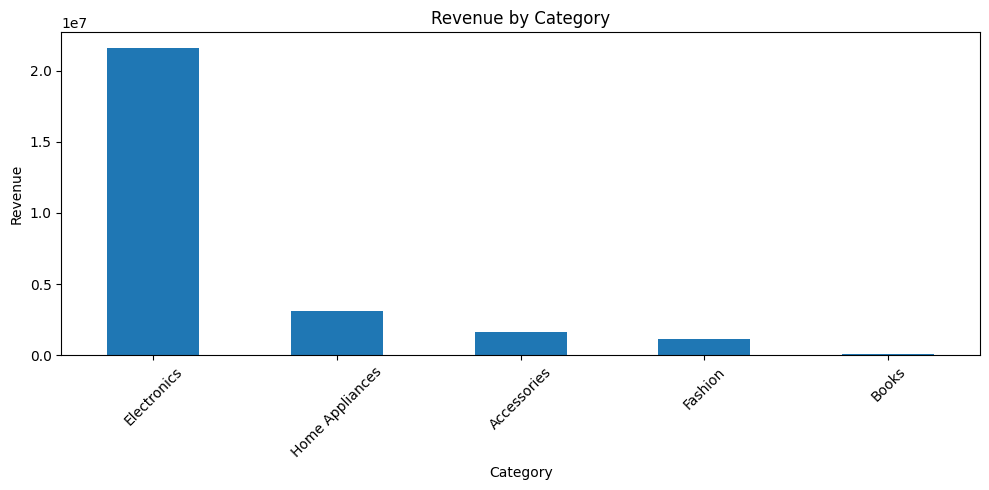

In [ ]:
# CATEGORY ANALYSIS
category_revenue = (df.groupby("category")["total_price"].sum().sort_values(ascending=False))

category_revenue

plt.figure(figsize=(10, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#QUANTITY BY CATEGORY
category_quantity = (df.groupby("category")["quantity"].sum().sort_values(ascending=False))

category_quantity

category
Electronics        1017
Fashion             679
Home Appliances     658
Accessories         482
Books               199
Name: quantity, dtype: int64

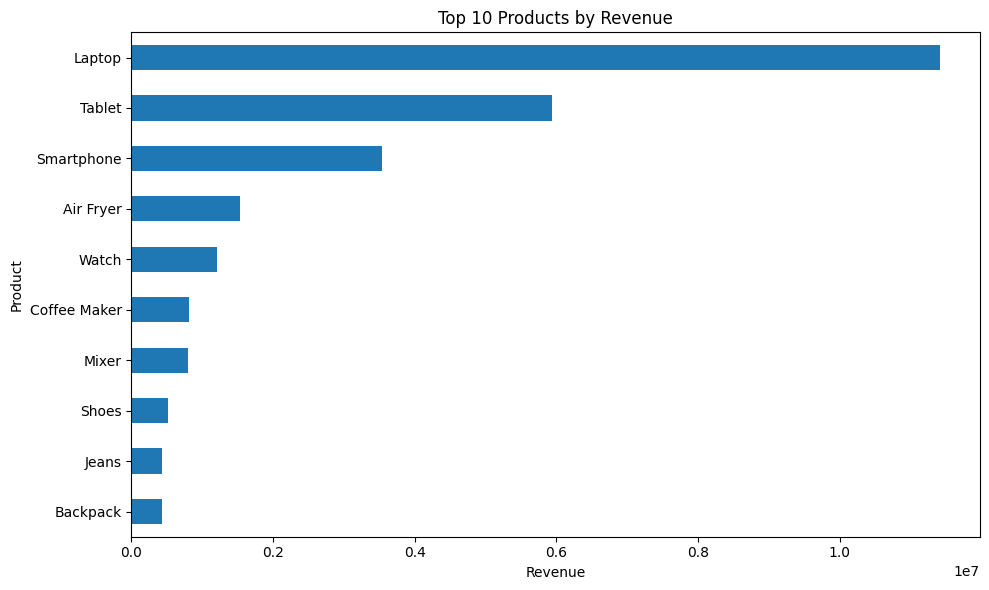

In [ ]:
#TOP 10 PRODUCTS BY REVENUE
top_products = (df.groupby("product")["total_price"].sum().sort_values(ascending=False).head(10))

top_products

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [24]:
#TOP 10 PRODUCTS BY QUANTITY
top_quantity_products = (df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(10))

top_quantity_products

product
T-Shirt      259
Backpack     241
Watch        241
Air Fryer    239
Mixer        226
Keyboard     218
Tablet       215
Jeans        214
Laptop       207
Shoes        206
Name: quantity, dtype: int64

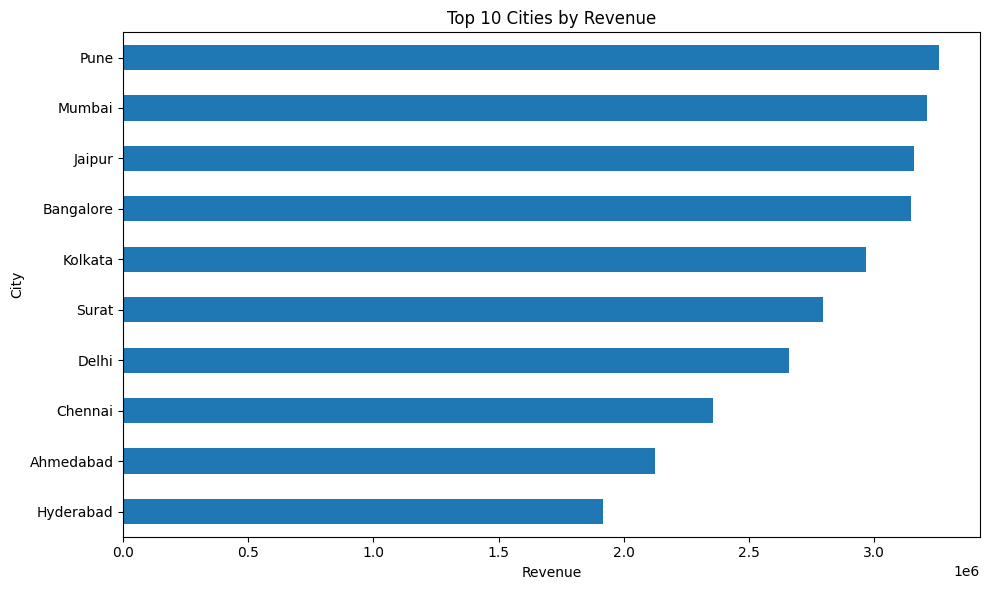

In [ ]:
#CITY ANALYSIS
city_revenue = (df.groupby("city")["total_price"].sum().sort_values(ascending=False))

city_revenue.head(10)

plt.figure(figsize=(10, 6))

city_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("City")
plt.tight_layout()
plt.show()

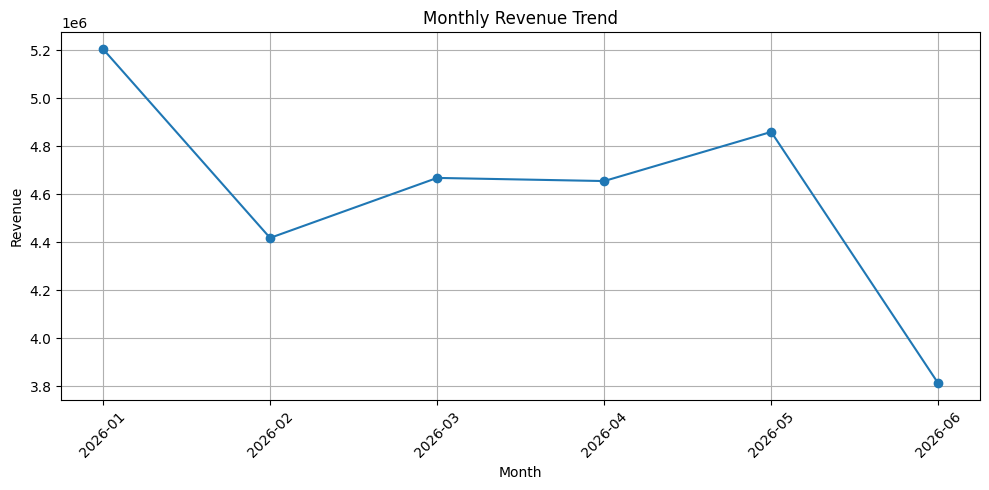

In [28]:
#MONTHLY REVENUE TREND
monthly_revenue = (df.groupby("month")["total_price"].sum().sort_index())

monthly_revenue

plt.figure(figsize=(10, 5))

monthly_revenue.plot(kind="line",marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

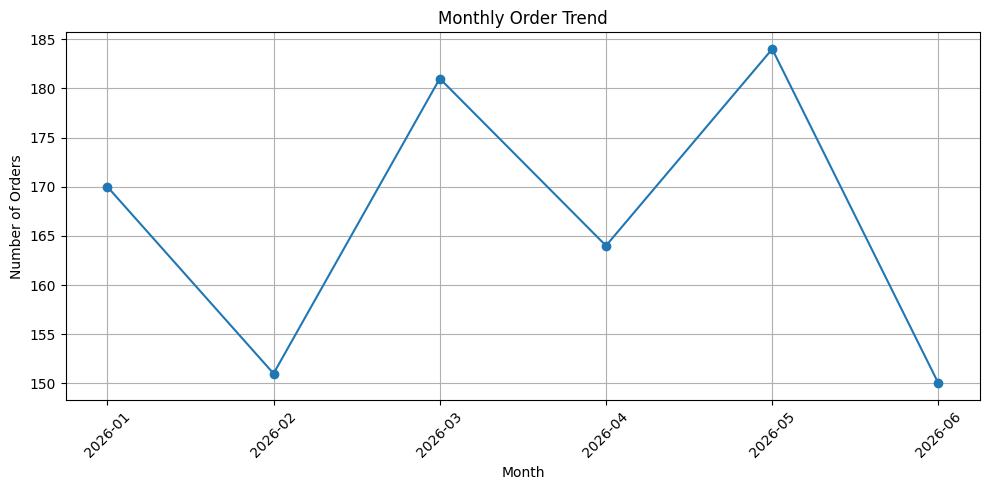

In [ ]:
#MONTHLY ORDERS
monthly_orders = (df.groupby("month")["order_id"].nunique().sort_index())

monthly_orders

plt.figure(figsize=(10, 5))

monthly_orders.plot(kind="line",marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [31]:
monthly_quantity = (df.groupby("month")["quantity"].sum().sort_index())

monthly_quantity

month
2026-01    521
2026-02    462
2026-03    532
2026-04    511
2026-05    522
2026-06    487
Name: quantity, dtype: int64

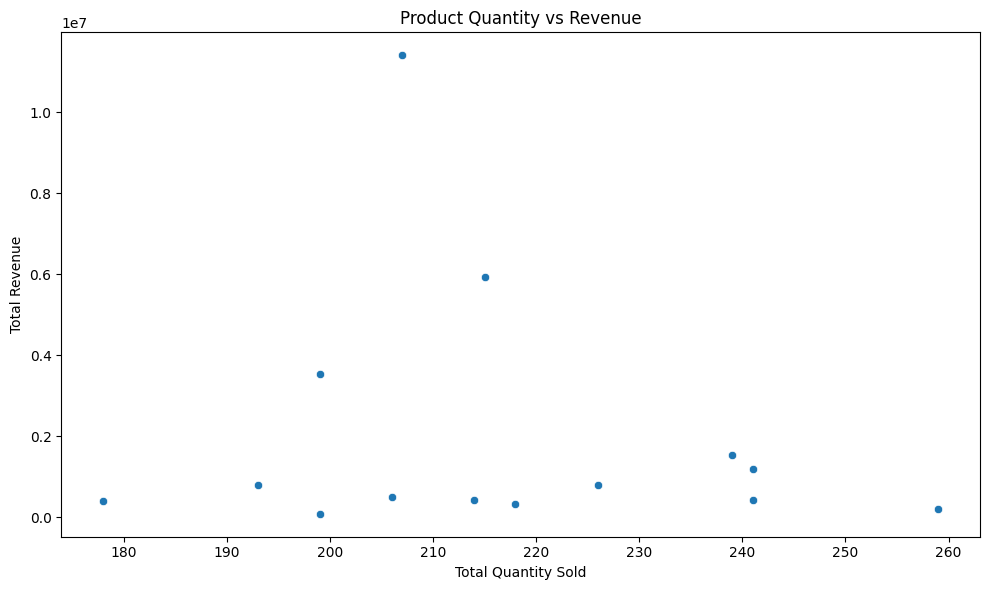

In [ ]:
#PRODUCT REVENUE VS QUANTITY
product_summary = (df.groupby("product").agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("total_price", "sum")
    )
    .reset_index())

product_summary.head()


plt.figure(figsize=(10, 6))
sns.scatterplot(data=product_summary,x="total_quantity",y="total_revenue")

plt.title("Product Quantity vs Revenue")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

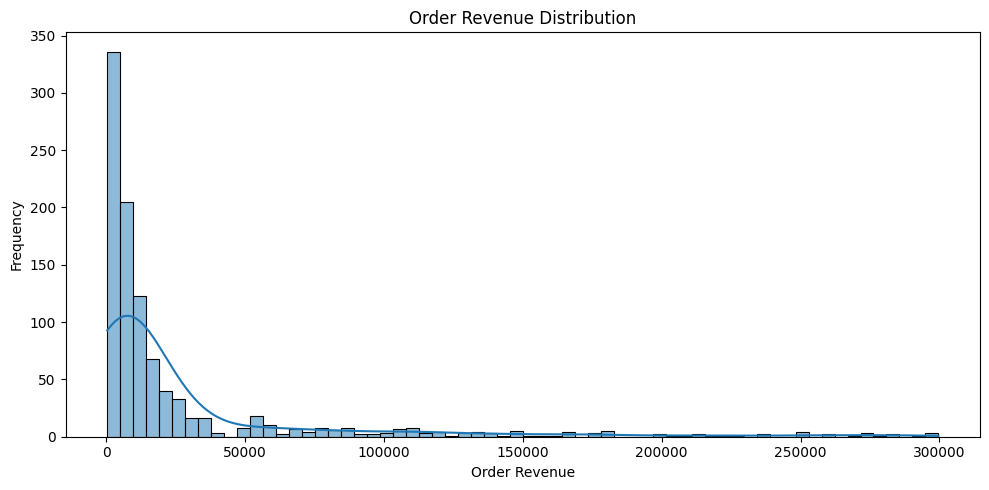

In [35]:
#REVENUE DISTRIBUTION

plt.figure(figsize=(10, 5))

sns.histplot(data=df,x="total_price",kde=True)

plt.title("Order Revenue Distribution")
plt.xlabel("Order Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

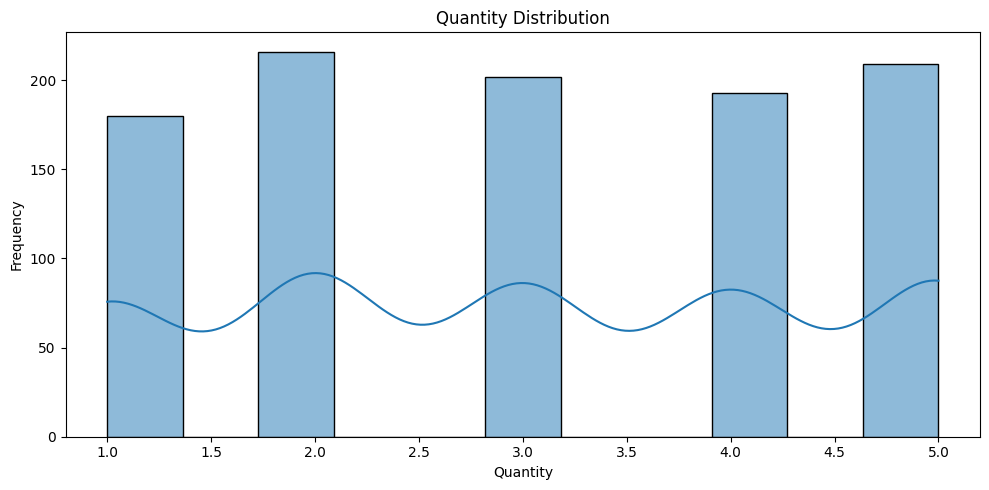

In [38]:
#QUANTITY DISTRIBUTION
plt.figure(figsize=(10, 5))

sns.histplot(data=df,x="quantity",kde=True)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

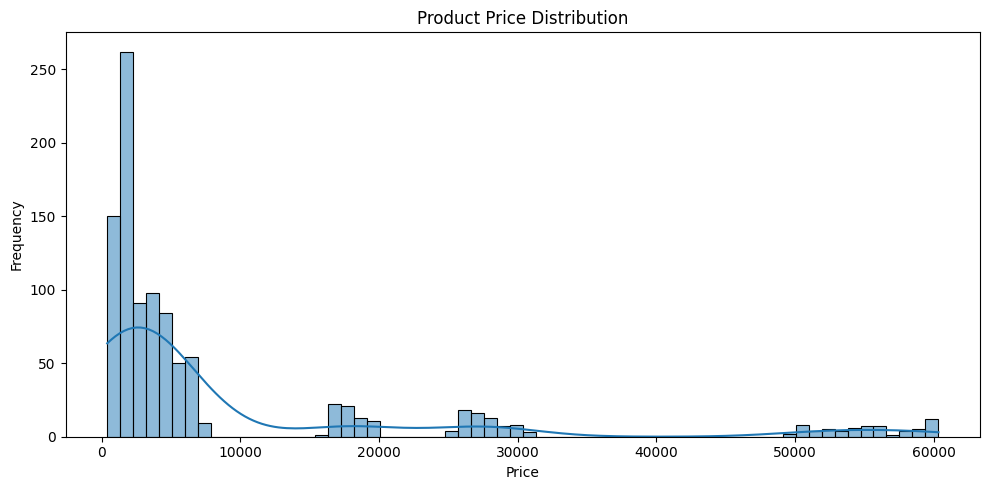

In [ ]:
#PRICE DISTRIBUTION
plt.figure(figsize=(10, 5))

sns.histplot(data=df,x="price",kde=True)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [41]:
Q1 = df["total_price"].quantile(0.25)
Q3 = df["total_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["total_price"] < lower_bound) |
    (df["total_price"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

outliers.head(10)

Q1: 3800.0725
Q3: 20335.4625
IQR: 16535.39
Lower Bound: -21003.012499999997
Upper Bound: 45138.5475
Number of Outliers: 160


,order_id,product,category,quantity,price,city,date,total_price,year,month_number,month
4,ORD1005,Tablet,Electronics,5,27549.31,Jaipur,2026-05-31,137746.55,2026,5,2026-05
9,ORD1010,Smartphone,Electronics,4,16483.68,Hyderabad,2026-06-10,65934.72,2026,6,2026-06
26,ORD1027,Smartphone,Electronics,4,17573.83,Jaipur,2026-05-16,70295.32,2026,5,2026-05
44,ORD1045,Smartphone,Electronics,5,17056.82,Jaipur,2026-02-24,85284.10,2026,2,2026-02
55,ORD1056,Laptop,Electronics,4,52417.23,Jaipur,2026-03-15,209668.92,2026,3,2026-03
58,ORD1059,Tablet,Electronics,5,25541.36,Pune,2026-01-15,127706.80,2026,1,2026-01
59,ORD1060,Laptop,Electronics,5,54744.67,Surat,2026-02-10,273723.35,2026,2,2026-02
60,ORD1061,Laptop,Electronics,5,50381.23,Delhi,2026-01-18,251906.15,2026,1,2026-01
62,ORD1063,Smartphone,Electronics,5,17086.38,Kolkata,2026-01-11,85431.90,2026,1,2026-01
65,ORD1066,Tablet,Electronics,3,26536.64,Chennai,2026-02-03,79609.92,2026,2,2026-02


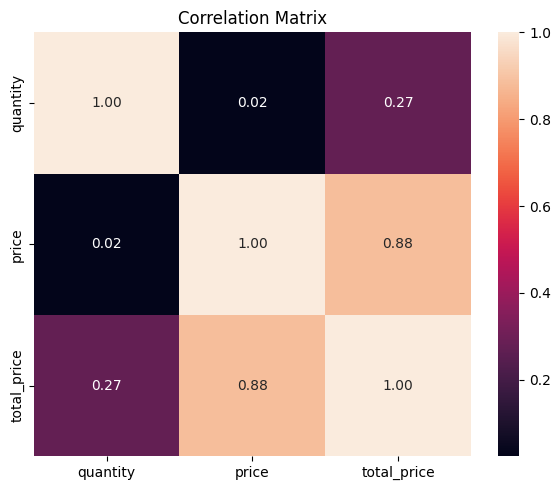

In [43]:
numeric_columns = ["quantity","price","total_price"]

correlation = df[numeric_columns].corr()

correlation

plt.figure(figsize=(6, 5))

sns.heatmap(correlation,annot=True,fmt=".2f")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Revenue concentration

Electronics dominates massively — ~₹21.6M vs. Home Appliances (~₹3.1M), Accessories (~₹1.6M), Fashion (~₹1.1M), and Books (negligible). Electronics alone is roughly 78% of total revenue.
Laptop is the single biggest product (~₹11.4M), followed by Tablet (~₹5.9M) and Smartphone (~₹3.5M) — these 3 products likely account for most of total revenue.

Geographic spread

Revenue is fairly evenly distributed across top cities (Pune, Mumbai, Jaipur, Bangalore, Kolkata all in the ₹2.9M–3.3M range), with Hyderabad and Ahmedabad trailing lowest among the top 10. No single city dominates like Electronics does for category.

Time trend

Revenue trended down from Jan (~₹5.2M) to Feb (~₹4.4M), recovered through Mar–May (peaking ~₹4.86M in May), then dropped sharply in Jun (~₹3.8M) — a ~26% decline from the January high, and June looks like an incomplete/partial month or a genuine slump worth flagging.
Order count doesn't track revenue 1:1: May had the most orders (184) but revenue was still below January's — meaning January had a higher average order value (fewer but pricier orders, consistent with Laptop/Tablet's high unit price).

Price/quantity/revenue relationships

Correlation matrix: quantity has almost no correlation with price (0.02) or total_price (0.27) — revenue is driven by price, not by how many units are sold.
Price and total_price are strongly correlated (0.88), confirming high-ticket items (Laptop, Tablet) drive revenue regardless of volume.
Quantity vs. revenue scatter shows no relationship — the highest-revenue product (Laptop) doesn't have the highest quantity sold; several lower-revenue products actually sold more units.

Distributions

Order revenue is heavily right-skewed — most orders are low value (bulk under ₹50K) with a long tail of outliers up to ~₹300K. This matches your outlier stats: 160 outliers out of 1,000 orders (16%) using the IQR method (bounds: -₹21,003 to ₹45,139), driven by high-ticket Electronics purchases.
Product prices are bimodal: a large cluster of low-priced items (~₹1K–5K, likely Accessories/Fashion/Books) and a smaller cluster of high-priced items (~₹15K–60K, likely Electronics), rather than a smooth continuum.
Quantity distribution (1–5 units) is roughly uniform, not skewed — customers don't consistently buy more or fewer units of any particular range.

## Key EDA Findings

### 1. Revenue Concentration
- Electronics is the dominant revenue-generating category, contributing approximately 78% of total revenue (~₹21.6M).
- Home Appliances (~₹3.1M), Accessories (~₹1.6M), and Fashion (~₹1.1M) contribute substantially less revenue, while Books contributes negligibly.
- Laptop is the highest-revenue product (~₹11.4M), followed by Tablet (~₹5.9M) and Smartphone (~₹3.5M), indicating that a small number of high-value Electronics products account for a significant share of total revenue.

### 2. Geographic Performance
- Revenue is relatively distributed across the major cities, with Pune, Mumbai, Jaipur, Bangalore, and Kolkata each generating approximately ₹2.9M–₹3.3M.
- Hyderabad and Ahmedabad record comparatively lower revenue among the analyzed cities.
- Unlike category performance, there is no single city with an overwhelming share of total revenue.

### 3. Time Trend
- Monthly revenue declined from approximately ₹5.2M in January to ₹4.4M in February.
- Revenue recovered from March through May, reaching a peak of approximately ₹4.86M in May.
- Revenue then declined sharply to approximately ₹3.8M in June, representing roughly a 26% decline from the January peak.
- June should be investigated further to determine whether the decline reflects a genuine sales slowdown or an incomplete reporting period.

### 4. Order Volume vs Revenue
- May recorded the highest number of orders (184), but its revenue remained below January's revenue.
- This indicates that order volume alone does not explain revenue performance.
- January's higher revenue despite fewer orders suggests a higher Average Order Value (AOV), potentially influenced by higher-value Electronics purchases.

### 5. Price, Quantity and Revenue Relationships
- Quantity has very weak correlation with Price (0.02) and relatively weak correlation with Total Revenue (0.27).
- Price has a strong positive correlation with Total Revenue (0.88).
- These results indicate that revenue is more strongly associated with product price than sales quantity in this dataset.
- The quantity-versus-revenue analysis also shows that the highest-revenue products do not necessarily have the highest unit volumes.

### 6. Revenue Distribution and Outliers
- Order-level revenue is strongly right-skewed, with most orders concentrated at lower values and a long upper tail.
- The IQR method identified 160 potential outliers out of 1,000 orders (16%).
- The identified outliers are primarily associated with high-value transactions and should not automatically be treated as data errors.
- The negative lower IQR bound indicates that only the upper-bound condition is practically relevant for positive sales revenue.

### 7. Product Price Distribution
- Product prices show a bimodal distribution, with one cluster of lower-priced products (~₹1K–₹5K) and another cluster of higher-priced products (~₹15K–₹60K).
- This pattern is consistent with the presence of both lower-priced categories such as Accessories, Fashion, and Books and higher-priced Electronics products.

### 8. Quantity Distribution
- Quantity sold per order ranges approximately from 1 to 5 units and is relatively evenly distributed.
- There is no strong concentration toward either very low or very high quantities.
- This further supports the observation that product price, rather than purchase quantity, is a stronger driver of revenue in this dataset.